In [1]:
import uproot
import ROOT as r
import mplhep
import matplotlib.pyplot as plt
import numpy as np
plt.style.use(mplhep.style.CMS)

Welcome to JupyROOT 6.28/11


In [2]:
f = uproot.open('fitDiagnosticsTest.root')

f.keys()

['shapes_prefit;1',
 'shapes_prefit/ptbin0ggffail2022;1',
 'shapes_prefit/ptbin0ggffail2022/data;1',
 'shapes_prefit/ptbin0ggffail2022/TTbar;1',
 'shapes_prefit/ptbin0ggffail2022/VBF;1',
 'shapes_prefit/ptbin0ggffail2022/VV;1',
 'shapes_prefit/ptbin0ggffail2022/W;1',
 'shapes_prefit/ptbin0ggffail2022/WH;1',
 'shapes_prefit/ptbin0ggffail2022/ZH;1',
 'shapes_prefit/ptbin0ggffail2022/ZJetsbb;1',
 'shapes_prefit/ptbin0ggffail2022/ZJetsqq;1',
 'shapes_prefit/ptbin0ggffail2022/ggF;1',
 'shapes_prefit/ptbin0ggffail2022/ttH;1',
 'shapes_prefit/ptbin0ggffail2022/qcd;1',
 'shapes_prefit/ptbin0ggffail2022/total;1',
 'shapes_prefit/ptbin0ggffail2022/total_signal;1',
 'shapes_prefit/ptbin0ggffail2022/total_background;1',
 'shapes_prefit/ptbin0ggffail2022/total_covar;1',
 'shapes_prefit/ptbin0ggfpass2022;1',
 'shapes_prefit/ptbin0ggfpass2022/data;1',
 'shapes_prefit/ptbin0ggfpass2022/TTbar;1',
 'shapes_prefit/ptbin0ggfpass2022/VBF;1',
 'shapes_prefit/ptbin0ggfpass2022/VV;1',
 'shapes_prefit/ptbin0gg

/tmp/adlintul/ipykernel_18212/898704092.py:124: RuntimeWarning: divide by zero encountered in divide
  hs_mc_sub = np.sqrt(sumw2_mc) / np.sqrt(sumw2_data)
/tmp/adlintul/ipykernel_18212/898704092.py:125: RuntimeWarning: divide by zero encountered in divide
  rat_sub = (sumw_data - sumw_mc) / np.sqrt(sumw2_data)
/tmp/adlintul/ipykernel_18212/898704092.py:126: RuntimeWarning: invalid value encountered in divide
  rat_sub_unc = np.sqrt(sumw2_data) / np.sqrt(sumw2_data)
/tmp/adlintul/ipykernel_18212/898704092.py:127: RuntimeWarning: invalid value encountered in divide
  ggf_sub = h_ggf.values() / np.sqrt(sumw2_data)
/tmp/adlintul/ipykernel_18212/898704092.py:124: RuntimeWarning: divide by zero encountered in divide
  hs_mc_sub = np.sqrt(sumw2_mc) / np.sqrt(sumw2_data)
/tmp/adlintul/ipykernel_18212/898704092.py:125: RuntimeWarning: divide by zero encountered in divide
  rat_sub = (sumw_data - sumw_mc) / np.sqrt(sumw2_data)
/tmp/adlintul/ipykernel_18212/898704092.py:126: RuntimeWarning: inval

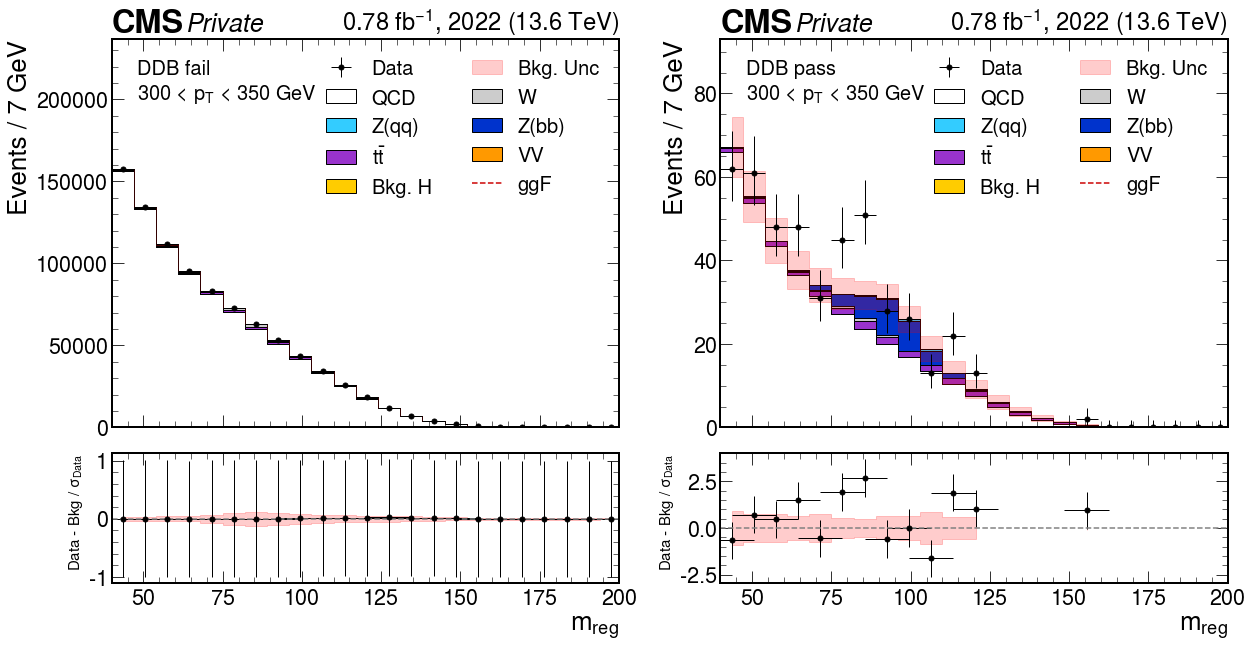

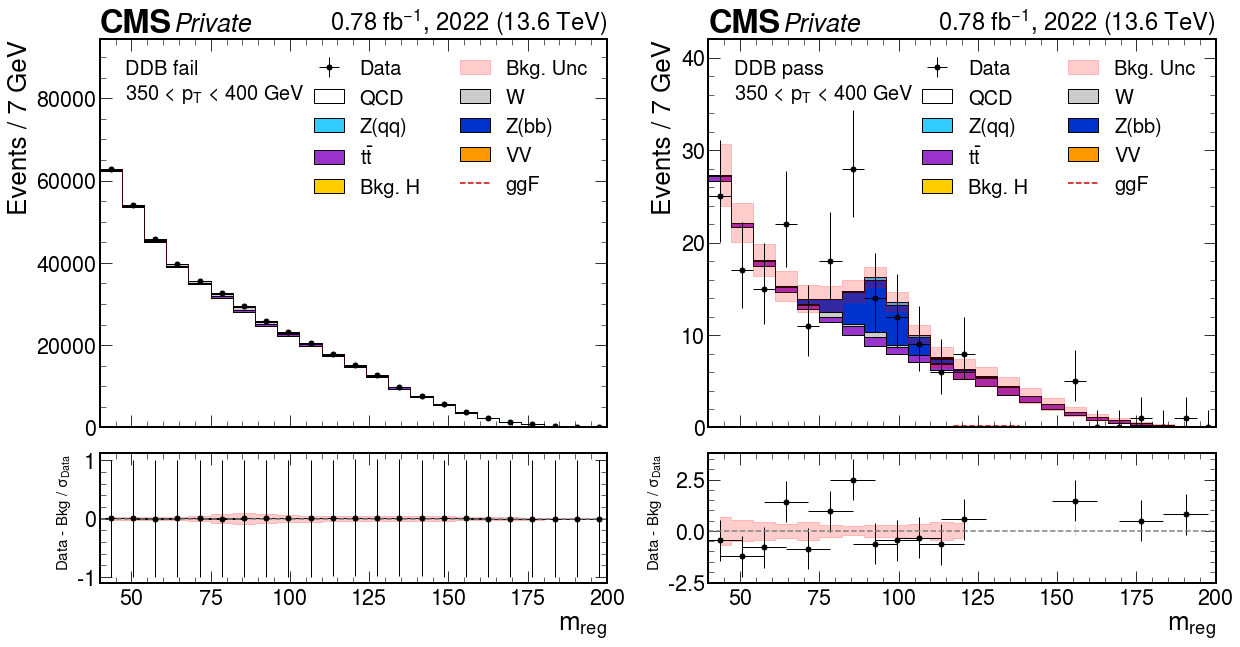

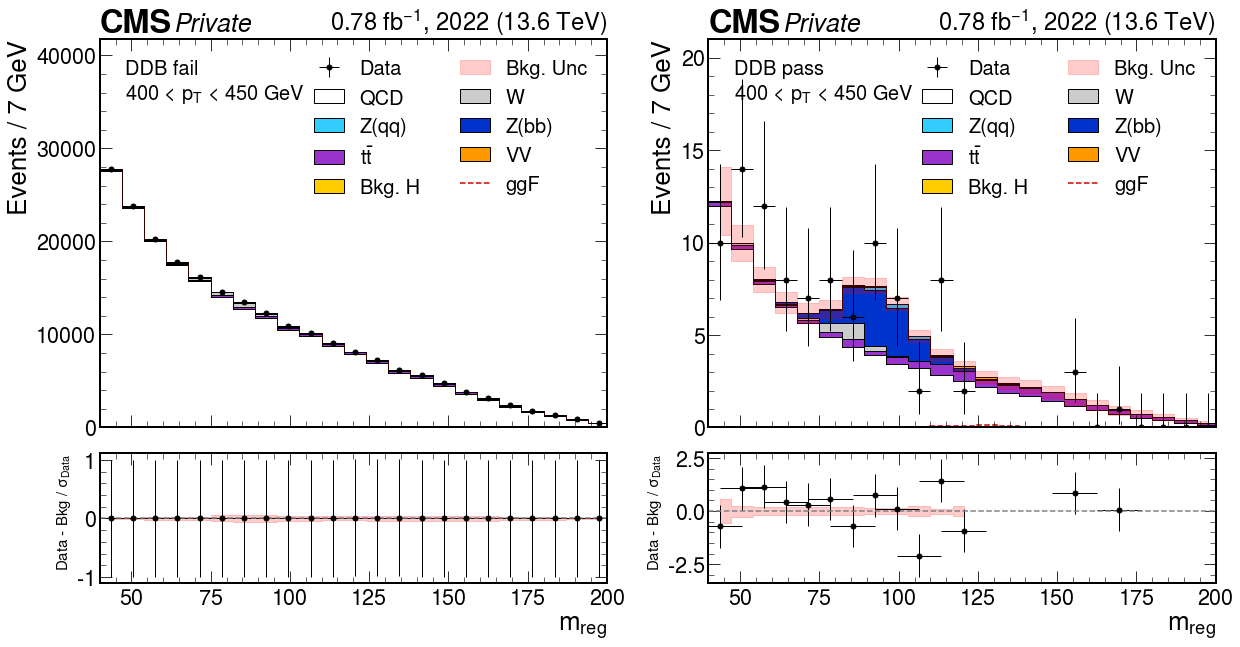

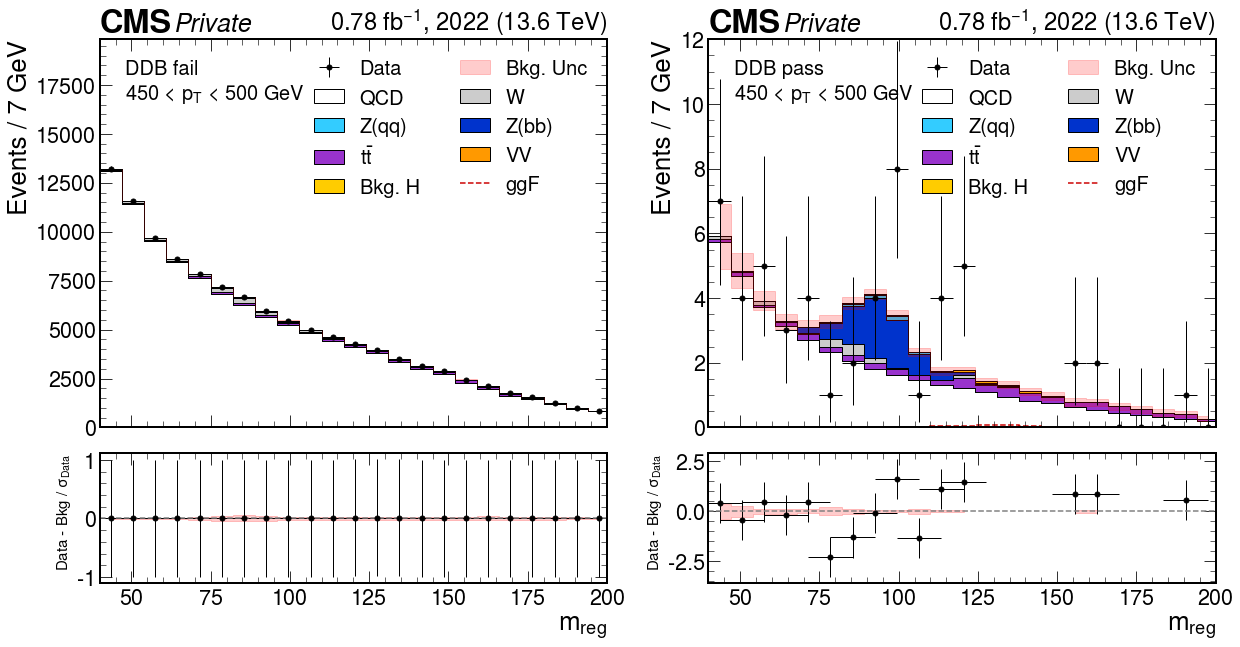

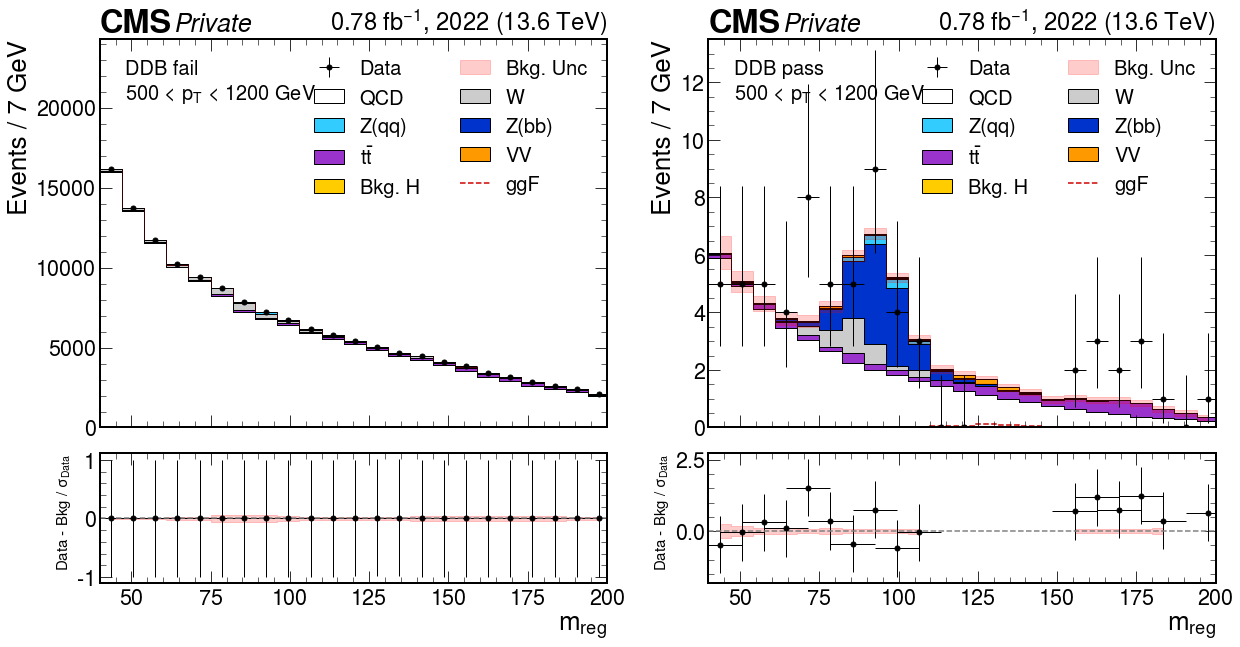

In [5]:
from coffea.hist import clopper_pearson_interval, poisson_interval
plt.style.use(mplhep.style.CMS)

colour = {
    "qcd" : "white",
    "TTbar" : "#9933cc",
    "W" : "#cccccc",
    "ZJetsbb" : "#0033cc",
    "ZJetsqq" : "#33ccff",
#     "Single t" : "#ff66cc",
    "VV" : "#ff9900",
}

label = {
    "qcd" : "QCD",
    "ZJetsbb" : "Z(bb)",
    "ZJetsqq" : "Z(qq)",
    "W" : "W",
    "TTbar" : r"$t\bar{t}$",
    "Single t" : "Single t",
    "VV" : "VV",
}

fit_type = 'prefit'
# fit_type = 'fit_s'

pts = [300, 350, 400, 450, 500, 1200] #550, 600, 675, 800, 1200]

for i, _ in enumerate(pts[:-1]):
    
    fig, ((ax1, ax2), (rax1, rax2)) = plt.subplots(
        2, 2, figsize=(20, 10), gridspec_kw={"height_ratios": (3, 1)}, sharex=True
    )
    fig.subplots_adjust(hspace=0.1)

    for reg, ax, rax in [('fail', ax1, rax1), ('pass', ax2, rax2)]:
    
        hs = []
        labels = []
        colours = []

        fig.subplots_adjust(hspace=0.1)
        ax.set_ylabel("Events / 7 GeV")
        rax.set_ylabel(r"Data - Bkg / $\sigma_{Data}$", fontsize=15)
        rax.set_xlabel(r"m$_{reg}$")
        ax.set_xlabel(" ")

        for process in colour.keys():

            h = f[f'shapes_{fit_type}/ptbin{i}ggf{reg}2022/{process}'].to_hist() * 7

            hs.append(h)
            labels.append(label[process])
            colours.append(colour[process])

        higgs_h = None

        for process in ['VBF', 'ZH', 'WH', 'ttH']:

            h = f[f'shapes_{fit_type}/ptbin{i}ggf{reg}2022/{process}'].to_hist() * 7

            if not higgs_h:
                higgs_h = h
            else:
                higgs_h += h

        hs.append(higgs_h)
        labels.append("Bkg. H")
        colours.append("#ffcc00")

        mplhep.histplot(
            hs,
            ax=ax,
            label=labels,
            stack=True,
            color=colours,
            histtype="fill",
            edgecolor="black",
            linewidth=1,
            flow="none",
        )

        h_ggf = f[f'shapes_{fit_type}/ptbin{i}ggf{reg}2022/ggF'].to_hist() * 7

        mplhep.histplot(
            h_ggf, 
            ax=ax,
            yerr=False,
            color="#cc0000",
            label=f"ggF",
            linestyle="dashed",
            flow="none",
        )

        data = uproot.open("signalregion.root")
        h_data = data[f'ggf_{reg}_pt{i+1}_data_nominal'].to_hist()
        if reg == "pass":
            for i_nan in [12, 13, 14, 15]:
                    h_data[i_nan] = [np.nan, np.nan]

        mplhep.histplot(
            h_data, 
            ax=ax, 
            histtype="errorbar",
            xerr=True,
            c="black",
            label=f"Data",
            flow="none",
        )

        hs_mc = f[f'shapes_{fit_type}/ptbin{i}ggf{reg}2022/total_background'].to_hist() * 7
        
        hs_mc_x = hs_mc.axes[0].centers
        hs_mc_y = hs_mc.values()
        hs_mc_unc = np.sqrt(hs_mc.variances())
        
        ax.fill_between(hs_mc_x, hs_mc_y - hs_mc_unc, hs_mc_y + hs_mc_unc,
                         step='mid', alpha=0.2, label='Bkg. Unc', color='red')

        centers = h_data.axes[0].centers
        sumw_data, sumw2_data = h_data.values(), h_data.variances()
        sumw_mc, sumw2_mc = hs_mc.values(), hs_mc.variances()
        
        hs_mc_sub = np.sqrt(sumw2_mc) / np.sqrt(sumw2_data)
        rat_sub = (sumw_data - sumw_mc) / np.sqrt(sumw2_data)
        rat_sub_unc = np.sqrt(sumw2_data) / np.sqrt(sumw2_data)
        ggf_sub = h_ggf.values() / np.sqrt(sumw2_data)

#         rsumw = sumw_num / np.maximum(1, sumw_denom)
#         rsumw_unc = poisson_interval(
#             rsumw,
#             sumw2_num / sumw_denom**2
#         )

        data_err_opts = {
            'linestyle': 'none',
            'marker': '.',
            'markersize': 10.,
            'color': 'k',
            'elinewidth': 1,
        }

#         rax.errorbar(
#             centers,
#             rsumw,
#             xerr=centers[1]-centers[0],
#             yerr=rsumw_unc,
#             **data_err_opts,
#         )

        rax.fill_between(centers, np.zeros(len(hs_mc_sub)) - hs_mc_sub, np.zeros(len(hs_mc_sub)) + hs_mc_sub,
                         step='mid', alpha=0.2, label='Bkg. Unc', color='red')

        rax.errorbar(
            centers,
            rat_sub,
            xerr=centers[1]-centers[0],
            yerr=rat_sub_unc,
            **data_err_opts,
        )

        rax.axhline(0, color='gray',ls='--')

        mplhep.cms.label(
            ax=ax, 
            data=True, 
            fontsize=25,
            label="Private",
            year=2022,
            lumi=f"{0.78:.2f}",
            com=13.6,
        )

        handles, labels = ax.get_legend_handles_labels()
        order = [9, 0, 4, 1, 6, 8, 2, 3, 5, 7]
        ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order], fontsize=20, ncols=2)

        ax.set_ylim(0, max(h_data.values()) * 1.5)
        
        plt.text(0.05, 0.83, f"DDB {reg}\n{pts[i]:.0f} < " + r"$p_T$" + f" < {pts[i+1]} GeV",
                    fontsize=20,
                    horizontalalignment='left',
                    verticalalignment='bottom',
                    transform=ax.transAxes
                   )
        
        ax.set_xlim(40, 200)